# AI-Driven Dynamic Pricing in an E-Commerce ERP System

**Academic ERP Research Project – Chapter 4 Experiment**  
**Dataset:** Olist Brazilian E-Commerce Public Dataset

---



## 0. Imports & Environment Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE   = os.getcwd()
DATA   = os.path.join(BASE, "data")
if not os.path.isdir(DATA):
    DATA = BASE

TABLES = os.path.join(BASE, "outputs", "tables")
FIGS   = os.path.join(BASE, "outputs", "figures")

os.makedirs(TABLES, exist_ok=True)
os.makedirs(FIGS,   exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)




DATA path set to: c:\UIT\Nam 2\Hoachdinhnguonluc\dynamic_pricing_project\project
  AI-Driven Dynamic Pricing – ERP Research Experiment


## Section 1 – Load and Merge Dataset

Load all Olist CSV files and merge them into a single transaction-level dataframe.  
Only **delivered** orders are kept.


In [2]:
print("\n[1] Loading and merging Olist datasets …")

# Read CSV files directly from current folder
orders      = pd.read_csv("olist_orders_dataset.csv")
items       = pd.read_csv("olist_order_items_dataset.csv")
products    = pd.read_csv("olist_products_dataset.csv")
customers   = pd.read_csv("olist_customers_dataset.csv")
payments    = pd.read_csv("olist_order_payments_dataset.csv")
reviews     = pd.read_csv("olist_order_reviews_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

# Keep only delivered orders
orders_delivered = orders[orders["order_status"] == "delivered"].copy()

# Aggregate payments to order level
payments_agg = (
    payments.groupby("order_id", as_index=False)["payment_value"].sum()
)

# Aggregate reviews to order level
reviews_agg = (
    reviews.groupby("order_id", as_index=False)["review_score"].mean()
)

# Merge pipeline
df = (
    items
    .merge(
        orders_delivered[
            ["order_id", "customer_id", "order_purchase_timestamp"]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
    .merge(
        customers[["customer_id", "customer_state"]],
        on="customer_id",
        how="left"
    )
    .merge(payments_agg, on="order_id", how="left")
    .merge(reviews_agg, on="order_id", how="left")
    .merge(translation, on="product_category_name", how="left")
)

# Use English category name where available
df["product_category_name"] = (
    df["product_category_name_english"]
    .fillna(df["product_category_name"])
)

df.drop(
    columns=["product_category_name_english"],
    errors="ignore",
    inplace=True
)

# Select required columns
cols = [
    "order_id",
    "customer_id",
    "product_id",
    "seller_id",
    "product_category_name",
    "order_purchase_timestamp",
    "price",
    "freight_value",
    "payment_value",
    "review_score",
    "customer_state"
]

df = df[cols].copy()

print(f"Raw merged rows: {len(df):,}")

df.head()


[1] Loading and merging Olist datasets …
Raw merged rows: 110,197


,order_id,customer_id,product_id,seller_id,product_category_name,order_purchase_timestamp,price,freight_value,payment_value,review_score,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,cool_stuff,2017-09-13 08:59:02,58.90,13.29,72.19,5.0,RJ
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,pet_shop,2017-04-26 10:53:06,239.90,19.93,259.83,4.0,SP
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,furniture_decor,2018-01-14 14:33:31,199.00,17.87,216.87,5.0,MG
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,perfumery,2018-08-08 10:00:35,12.99,12.79,25.78,4.0,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,garden_tools,2017-02-04 13:57:51,199.90,18.14,218.04,5.0,SP


## Section 2 – Data Preprocessing

- Remove duplicates  
- Parse timestamps and extract time features  
- Fill missing values  
- Remove price outliers (1st–99th percentile)


In [3]:
print("\n[2] Preprocessing …")

# Drop duplicates
df.drop_duplicates(inplace=True)

# Parse timestamps
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

# Time features
df["date"]        = df["order_purchase_timestamp"].dt.date
df["week"]        = df["order_purchase_timestamp"].dt.to_period("W").apply(lambda r: r.start_time)
df["month"]       = df["order_purchase_timestamp"].dt.to_period("M").apply(lambda r: r.start_time)
df["day_of_week"] = df["order_purchase_timestamp"].dt.dayofweek
df["is_weekend"]  = df["day_of_week"].isin([5, 6]).astype(int)

# Handle missing values
df["review_score"].fillna(df["review_score"].median(), inplace=True)
df["product_category_name"].fillna("unknown", inplace=True)
df["payment_value"].fillna(df["price"] + df["freight_value"], inplace=True)

# Remove price outliers (keep 1st–99th percentile)
p1, p99 = df["price"].quantile([0.01, 0.99])
df = df[(df["price"] >= p1) & (df["price"] <= p99)]

print(f"   Clean rows after preprocessing: {len(df):,}")
print(f"   Date range: {df['order_purchase_timestamp'].min().date()} "
      f"→ {df['order_purchase_timestamp'].max().date()}")

df.describe()



[2] Preprocessing …
   Clean rows after preprocessing: 98,212
   Date range: 2016-09-15 → 2018-08-29


,order_purchase_timestamp,price,freight_value,payment_value,review_score,week,month,day_of_week,is_weekend
count,98212,98212.000000,98212.000000,98211.000000,97541.000000,98212,98212,98212.000000,98212.000000
mean,2018-01-02 05:33:38.796644,111.491869,19.745805,150.844400,4.128153,2017-12-29 20:06:09.193173,2017-12-18 01:21:14.581517,2.757616,0.230277
min,2016-09-15 12:16:38,10.910000,0.000000,18.300000,1.000000,2016-09-12 00:00:00,2016-09-01 00:00:00,0.000000,0.000000
25%,2017-09-14 16:15:56,41.990000,13.140000,63.520000,4.000000,2017-09-11 00:00:00,2017-09-01 00:00:00,1.000000,0.000000
50%,2018-01-20 18:37:04.500000,78.000000,16.320000,107.660000,5.000000,2018-01-15 00:00:00,2018-01-01 00:00:00,3.000000,0.000000
75%,2018-05-05 19:13:33,135.900000,21.120000,179.040000,5.000000,2018-04-30 00:00:00,2018-05-01 00:00:00,4.000000,0.000000
max,2018-08-29 15:00:37,899.000000,312.410000,3242.840000,5.000000,2018-08-27 00:00:00,2018-08-01 00:00:00,6.000000,1.000000
std,NaN,116.067590,14.466045,151.645255,1.306928,NaN,NaN,1.967750,0.421012


## Section 3 – Demand Aggregation

Aggregate demand by **product category × month**.  
Identify the **top 10 categories** by total volume.


In [4]:
print("\n[3] Aggregating demand by product category × month …")

demand = (
    df.groupby(["month", "product_category_name"], as_index=False)
    .agg(
        total_quantity   = ("order_id",      "count"),
        avg_price        = ("price",         "mean"),
        avg_freight      = ("freight_value", "mean"),
        avg_review_score = ("review_score",  "mean"),
        total_revenue    = ("payment_value", "sum"),
    )
)
demand["month"] = pd.to_datetime(demand["month"])
demand.sort_values(["product_category_name", "month"], inplace=True)

# Top categories by total volume
top_cats = (
    demand.groupby("product_category_name")["total_quantity"]
    .sum().nlargest(10).index.tolist()
)
print(f"   Top 10 categories: {top_cats}")

demand_top = demand[demand["product_category_name"].isin(top_cats)].copy()
demand_top.head()



[3] Aggregating demand by product category × month …
   Top 10 categories: ['bed_bath_table', 'health_beauty', 'sports_leisure', 'computers_accessories', 'furniture_decor', 'housewares', 'watches_gifts', 'telephony', 'toys', 'auto']


,month,product_category_name,total_quantity,avg_price,avg_freight,avg_review_score,total_revenue
3,2016-10-01,auto,6,184.726667,33.295000,3.166667,1308.13
32,2017-01-01,auto,26,159.712692,18.863077,3.653846,6257.74
72,2017-02-01,auto,73,143.923288,23.375479,4.277778,14732.83
122,2017-03-01,auto,70,146.702286,25.448286,4.371429,14747.63
173,2017-04-01,auto,79,160.036962,25.721772,4.025316,17283.92


## Section 4 – Feature Engineering

Create lag features (1, 2, 3 months) and a 3-month rolling mean for each category.  
Encode the category label and drop rows with NaN lags.


In [5]:
print("\n[4] Engineering lag & rolling features …")

demand_top = demand_top.sort_values(["product_category_name", "month"]).copy()
for lag in [1, 2, 3]:
    demand_top[f"demand_lag_{lag}"] = demand_top.groupby("product_category_name")["total_quantity"].shift(lag)
demand_top["rolling_mean_3"] = demand_top.groupby("product_category_name")["total_quantity"].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
demand_feat = demand_top.copy()

# Month number
demand_feat["month_num"] = demand_feat["month"].dt.month

# Encode category
le = LabelEncoder()
demand_feat["category_enc"] = le.fit_transform(demand_feat["product_category_name"])

# Drop rows with NaN lags
demand_feat.dropna(inplace=True)
demand_feat.reset_index(drop=True, inplace=True)
print(f"   Feature matrix rows: {len(demand_feat):,}")

# Save modelling table
demand_feat.to_csv(os.path.join(TABLES, "demand_model_table.csv"), index=False)
demand_feat.head()



[4] Engineering lag & rolling features …
   Feature matrix rows: 181


,month,product_category_name,total_quantity,avg_price,avg_freight,avg_review_score,total_revenue,demand_lag_1,demand_lag_2,demand_lag_3,rolling_mean_3,month_num,category_enc
0,2017-03-01,auto,70,146.702286,25.448286,4.371429,14747.63,73.0,26.0,6.0,35.000000,3,0
1,2017-04-01,auto,79,160.036962,25.721772,4.025316,17283.92,70.0,73.0,26.0,56.333333,4,0
2,2017-05-01,auto,101,116.490297,23.237723,4.079208,17495.11,79.0,70.0,73.0,74.000000,5,0
3,2017-06-01,auto,96,122.194792,19.210208,4.202128,16082.01,101.0,79.0,70.0,83.333333,6,0
4,2017-07-01,auto,102,89.971765,19.374608,4.259804,12958.74,96.0,101.0,79.0,92.000000,7,0


## Section 5 – Demand Forecasting

Three models are trained and evaluated on a time-ordered 80/20 train-test split:

| Model | Type |
|---|---|
| Linear Regression | Baseline |
| Random Forest | AI – tabular ensemble |
| LSTM | AI – recurrent neural network |

Evaluation metrics: **MAE**, **RMSE**, **MAPE**


In [6]:
FEATURES = ["demand_lag_1", "demand_lag_2", "demand_lag_3",
            "rolling_mean_3", "avg_price", "avg_freight",
            "avg_review_score", "month_num", "category_enc"]
TARGET = "total_quantity"

# ── Time-ordered train/test split (80 / 20) ─────────────────────────────────
demand_feat.sort_values("month", inplace=True)
split = int(len(demand_feat) * 0.80)
train = demand_feat.iloc[:split]
test  = demand_feat.iloc[split:]

X_train, y_train = train[FEATURES].values, train[TARGET].values
X_test,  y_test  = test[FEATURES].values,  test[TARGET].values

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")


Train size: 144 | Test size: 37


### 5A – Linear Regression (Baseline)

In [7]:
print("   5A: Linear Regression baseline …")
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("   Done.")


   5A: Linear Regression baseline …
   Done.


### 5B – Random Forest

In [8]:
print("   5B: Random Forest model …")
rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("   Done.")


   5B: Random Forest model …
   Done.


### 5C – LSTM Neural Network

In [9]:
print("   5C: LSTM model …")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

# Reshape for LSTM: (samples, timesteps=1, features)
X_train_lstm = X_train_s.reshape(-1, 1, X_train_s.shape[1])
X_test_lstm  = X_test_s.reshape(-1, 1, X_test_s.shape[1])

lstm_model = Sequential([
    LSTM(64, input_shape=(1, X_train_s.shape[1]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train_s,
    epochs=100, batch_size=16,
    validation_split=0.15,
    callbacks=[es],
    verbose=1
)

y_pred_lstm_s = lstm_model.predict(X_test_lstm, verbose=0).ravel()
y_pred_lstm   = scaler_y.inverse_transform(y_pred_lstm_s.reshape(-1, 1)).ravel()
print("   Done.")


   5C: LSTM model …
Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.1031 - val_loss: 0.1843
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0815 - val_loss: 0.1413
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0587 - val_loss: 0.0974
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0405 - val_loss: 0.0581
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0355 - val_loss: 0.0356
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0310 - val_loss: 0.0284
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0298 - val_loss: 0.0282
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0279 - val_loss: 0.0270
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0237 - val_loss: 0.0213
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0206 - val_loss: 0.0154
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0187 - val_loss: 0.0119
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - l

### 5D – Evaluation

In [10]:
def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def eval_model(name, y_true, y_pred):
    return {
        "Model": name,
        "MAE":  round(mean_absolute_error(y_true, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_true, y_pred)), 2),
        "MAPE": round(mape(y_true, y_pred), 2),
    }

forecast_eval = pd.DataFrame([
    eval_model("Linear Regression (Baseline)", y_test, y_pred_lr),
    eval_model("Random Forest (AI Model)",     y_test, y_pred_rf),
    eval_model("LSTM (AI Model)",              y_test, y_pred_lstm),
])

print("\n   Demand Forecasting Evaluation:")
display(forecast_eval)
forecast_eval.to_csv(os.path.join(TABLES, "forecast_evaluation.csv"), index=False)

pred_map = {
    "Linear Regression (Baseline)": y_pred_lr,
    "Random Forest (AI Model)": y_pred_rf,
    "LSTM (AI Model)": y_pred_lstm,
}

best_model_name = forecast_eval.sort_values("RMSE").iloc[0]["Model"]
best_pred = pred_map[best_model_name]

print(f"Best forecasting model based on RMSE: {best_model_name}")




   Demand Forecasting Evaluation:


,Model,MAE,RMSE,MAPE
0,Linear Regression (Baseline),62.02,80.38,15.83
1,Random Forest (AI Model),84.41,104.39,22.13
2,LSTM (AI Model),72.66,93.71,20.84


Best forecasting model based on RMSE: Linear Regression (Baseline)


## Section 6 – Dynamic Price Optimisation

1. Estimate **price elasticity** per category via log-log OLS regression  
2. **Grid-search** over ±20% of current price (41 candidates) maximising elasticity-adjusted revenue  
3. Apply **business rules**: inventory clearance override, demand-high uplift


In [11]:
print("\n[6] Dynamic price optimisation …")

def estimate_elasticity(grp, default_elasticity=-1.0):
    grp = grp.dropna(subset=["avg_price", "total_quantity"])
    if len(grp) < 5 or grp["avg_price"].std() < 0.01:
        return default_elasticity

    ln_q = np.log(grp["total_quantity"].clip(lower=1))
    ln_p = np.log(grp["avg_price"].clip(lower=0.01))

    if ln_p.std() < 0.001:
        return default_elasticity

    corr = np.corrcoef(ln_p, ln_q)[0, 1]
    slope = corr * (ln_q.std() / ln_p.std())

    # Price elasticity should normally be negative.
    # If estimated elasticity is zero or positive, use conservative default.
    if np.isnan(slope) or slope >= 0:
        return default_elasticity

    return float(np.clip(slope, -3.0, -0.2))


elasticity_map = (
    demand_top
    .groupby("product_category_name")
    .apply(estimate_elasticity)
    .to_dict()
)

print("   Elasticity per category:")
for k, v in elasticity_map.items():
    print(f"     {k:<35} {v:.3f}")



[6] Dynamic price optimisation …
   Elasticity per category:
     auto                                -3.000
     bed_bath_table                      -1.000
     computers_accessories               -1.000
     furniture_decor                     -1.000
     health_beauty                       -1.000
     housewares                          -0.200
     sports_leisure                      -3.000
     telephony                           -1.000
     toys                                -1.162
     watches_gifts                       -3.000


In [ ]:
def optimise_price(current_price, forecasted_demand, elasticity,
                   min_price_ratio=0.80, max_price_ratio=1.20,
                   inventory_pressure=False, demand_high=False):
    """Grid-search over candidate prices; pick the one maximising revenue."""
    candidates = np.linspace(
        current_price * min_price_ratio,
        current_price * max_price_ratio,
        41
    )
    best_rev, best_price = -np.inf, current_price
    for p in candidates:
        pct_change = (p - current_price) / (current_price + 1e-9)
        adj_demand = forecasted_demand * (1 + elasticity * pct_change)
        adj_demand = max(adj_demand, 0)
        rev = p * adj_demand
        if rev > best_rev:
            best_rev   = rev
            best_price = p
    # Override with business rules
    if inventory_pressure and best_price >= current_price:
        best_price = current_price * 0.90
    if demand_high and best_price <= current_price:
        best_price = current_price * 1.05
    best_price = max(best_price, current_price * min_price_ratio)
    return round(best_price, 2)


def adjusted_demand_after_price_change(forecasted_demand, current_price, new_price, elasticity):
    pct_change = (new_price - current_price) / (current_price + 1e-9)
    adjusted_demand = forecasted_demand * (1 + elasticity * pct_change)
    return max(adjusted_demand, 0)


# Build optimisation table on test set
test_copy = test.copy().reset_index(drop=True)
test_copy["pred_demand_best"] = best_pred


results = []
for _, row in test_copy.iterrows():
    cat         = row["product_category_name"]
    cur_price   = row["avg_price"]
    fcst_demand = max(row["pred_demand_best"], 1)
    elast       = elasticity_map.get(cat, -1.0)

    # Fix 3: use only forecast & historical features — no actual future demand
    baseline_demand = row["rolling_mean_3"] if not np.isnan(row["rolling_mean_3"]) else row["demand_lag_1"]
    inv_pressure = fcst_demand < baseline_demand * 0.70
    dem_high     = fcst_demand > baseline_demand * 1.10

    rec_price = optimise_price(cur_price, fcst_demand, elast,
                               inventory_pressure=inv_pressure,
                               demand_high=dem_high)

    if dem_high:
        rule_price = round(cur_price * 1.05, 2)
    elif inv_pressure:
        rule_price = round(cur_price * 0.90, 2)
    else:
        rule_price = cur_price

    # Fix 4: revenue uses adjusted demand after price change
    ai_adj_demand   = adjusted_demand_after_price_change(fcst_demand, cur_price, rec_price, elast)
    rule_adj_demand = adjusted_demand_after_price_change(fcst_demand, cur_price, rule_price, elast)

    exp_rev_ai     = rec_price  * ai_adj_demand
    exp_rev_rule   = rule_price * rule_adj_demand
    exp_rev_static = cur_price  * fcst_demand

    results.append({
        "product_category_name": cat,
        "month":                 row["month"],
        "current_price":         round(cur_price, 2),
        "forecasted_demand":     round(fcst_demand, 1),
        "ai_adjusted_demand":    round(ai_adj_demand, 1),
        "rule_adjusted_demand":  round(rule_adj_demand, 1),
        "static_price":          round(cur_price, 2),
        "rule_price":            rule_price,
        "ai_price":              rec_price,
        "exp_rev_static":        round(exp_rev_static, 2),
        "exp_rev_rule":          round(exp_rev_rule, 2),
        "exp_rev_ai":            round(exp_rev_ai, 2),
        "inventory_pressure":    inv_pressure,
        "demand_high":           dem_high,
    })

results_df = pd.DataFrame(results)
display(results_df.head(10))


,product_category_name,month,current_price,forecasted_demand,ai_adjusted_demand,rule_adjusted_demand,static_price,rule_price,ai_price,exp_rev_static,exp_rev_rule,exp_rev_ai,inventory_pressure,demand_high
0,telephony,2018-05-01,64.16,284.9,284.9,284.9,64.16,64.164612,64.16,18280.93,18280.93,18280.93,False,False
1,bed_bath_table,2018-05-01,92.91,665.1,665.1,665.1,92.91,92.905496,92.91,61791.69,61791.69,61791.69,False,False
2,furniture_decor,2018-05-01,97.68,447.8,447.8,447.8,97.68,97.676563,97.68,43744.27,43744.27,43744.27,False,False
3,health_beauty,2018-05-01,115.36,572.3,572.3,572.3,115.36,115.364516,115.36,66020.05,66020.05,66020.05,False,False
4,watches_gifts,2018-05-01,173.64,461.4,392.3,392.3,173.64,182.320000,182.32,80123.39,71515.34,71515.34,False,True
5,housewares,2018-05-01,101.43,342.0,328.3,342.0,101.43,101.431899,121.72,34686.89,34686.89,39959.72,False,False
6,computers_accessories,2018-05-01,93.77,585.5,585.5,585.5,93.77,93.770199,93.77,54898.45,54898.45,54898.45,False,False
7,telephony,2018-06-01,77.99,264.7,264.7,264.7,77.99,77.985226,77.99,20641.33,20641.33,20641.33,False,False
8,furniture_decor,2018-06-01,105.94,448.0,448.0,448.0,105.94,105.944110,105.94,47463.65,47463.65,47463.65,False,False
9,health_beauty,2018-06-01,114.96,573.7,573.7,573.7,114.96,114.961815,114.96,65956.54,65956.54,65956.54,False,False


## Section 7 – Pricing Method Comparison

Compare three strategies:
- **Static Pricing** – keep historical average price unchanged  
- **Rule-Based Pricing** – +5% if high demand; −10% if inventory pressure  
- **AI Dynamic Pricing** – grid-search maximising elasticity-adjusted revenue


In [13]:
print("\n[7] Pricing method comparison …")

pricing_comparison = pd.DataFrame([
    {
        "Method":                 "Static Pricing",
        "Avg Recommended Price":  results_df["static_price"].mean().round(2),
        "Avg Forecasted Demand":  results_df["forecasted_demand"].mean().round(1),
        "Total Expected Revenue": results_df["exp_rev_static"].sum().round(2),
        "Revenue vs Static (%)":  "0.00%",
        "Notes":                  "Keeps historical average price unchanged",
    },
    {
        "Method":                 "Rule-Based Pricing",
        "Avg Recommended Price":  results_df["rule_price"].mean().round(2),
        "Avg Forecasted Demand":  results_df["forecasted_demand"].mean().round(1),
        "Total Expected Revenue": results_df["exp_rev_rule"].sum().round(2),
        "Revenue vs Static (%)":  f"{((results_df['exp_rev_rule'].sum() / results_df['exp_rev_static'].sum()) - 1) * 100:.2f}%",
        "Notes":                  "+5% if high demand; −10% if low / inventory pressure",
    },
    {
        "Method":                 "AI Dynamic Pricing",
        "Avg Recommended Price":  results_df["ai_price"].mean().round(2),
        "Avg Forecasted Demand":  results_df["forecasted_demand"].mean().round(1),
        "Total Expected Revenue": results_df["exp_rev_ai"].sum().round(2),
        "Revenue vs Static (%)":  f"{((results_df['exp_rev_ai'].sum() / results_df['exp_rev_static'].sum()) - 1) * 100:.2f}%",
        "Notes":                  "Grid-search maximising elasticity-adjusted revenue",
    },
])

display(pricing_comparison)
pricing_comparison.to_csv(os.path.join(TABLES, "pricing_comparison.csv"), index=False)



[7] Pricing method comparison …


,Method,Avg Recommended Price,Avg Forecasted Demand,Total Expected Revenue,Revenue vs Static (%),Notes
0,Static Pricing,108.69,427.4,1740995.18,0.00%,Keeps historical average price unchanged
1,Rule-Based Pricing,109.22,427.4,1732238.99,-0.50%,+5% if high demand; −10% if low / inventory pr...
2,AI Dynamic Pricing,104.83,427.4,1887425.43,8.41%,Grid-search maximising elasticity-adjusted rev...


## Section 8 – ERP Integration Output

Generate structured pricing recommendations consumable by an ERP system,  
including pricing **action labels**, **reasoning**, and an **approval flag**.


In [14]:
print("\n[8] Generating ERP pricing recommendation output …")

def pricing_action(row):
    delta = (row["ai_price"] - row["current_price"]) / (row["current_price"] + 1e-9)
    if abs(delta) < 0.01:
        return "Keep Price", "Demand stable; current price optimal", False
    elif delta > 0.10:
        return "Increase Price", "High demand forecasted; margin opportunity", True
    elif delta < -0.10:
        return "Clearance Discount", "Inventory pressure or low demand detected", True
    elif delta > 0:
        return "Increase Price", "Moderate demand growth; small price lift recommended", False
    else:
        return "Manager Review Required", "Price reduction flagged for approval", True

erp_rows = []
for _, row in results_df.iterrows():
    action, reason, approval = pricing_action(row)
    erp_rows.append({
        "product_category":   row["product_category_name"],
        "period":             str(row["month"])[:7],
        "current_price":      row["current_price"],
        "forecasted_demand":  row["forecasted_demand"],
        "recommended_price":  row["ai_price"],
        "expected_revenue":   row["exp_rev_ai"],
        "pricing_action":     action,
        "reason":             reason,
        "approval_required":  "Yes" if approval else "No",
    })

erp_df = pd.DataFrame(erp_rows)

# Sample: latest period per category
erp_sample = (
    erp_df.sort_values("period")
    .groupby("product_category", as_index=False)
    .last()
)
display(erp_sample[["product_category", "current_price", "forecasted_demand",
                     "recommended_price", "pricing_action", "approval_required"]])

erp_df.to_csv(os.path.join(TABLES, "erp_pricing_output.csv"), index=False)
erp_sample.to_csv(os.path.join(TABLES, "erp_pricing_sample.csv"), index=False)



[8] Generating ERP pricing recommendation output …


,product_category,current_price,forecasted_demand,recommended_price,pricing_action,approval_required
0,auto,98.82,308.3,79.05,Clearance Discount,Yes
1,bed_bath_table,89.73,611.4,89.73,Keep Price,No
2,computers_accessories,97.33,375.9,97.33,Keep Price,No
3,furniture_decor,101.85,355.0,101.85,Keep Price,No
4,health_beauty,128.37,672.0,128.37,Keep Price,No
5,housewares,91.41,425.8,109.69,Increase Price,Yes
6,sports_leisure,97.41,375.3,77.93,Clearance Discount,Yes
7,telephony,123.09,264.1,129.25,Increase Price,No
8,toys,107.00,193.2,99.51,Manager Review Required,Yes
9,watches_gifts,146.12,489.0,116.90,Clearance Discount,Yes


## Section 9 – Visualisations

Five figures are generated and saved to `outputs/figures/`:

1. Monthly demand trend – top 5 categories  
2. Actual vs Predicted demand (test set)  
3. Expected revenue by pricing method  
4. Distribution of AI-recommended price changes  
5. LSTM training & validation loss


In [15]:
PALETTE = sns.color_palette("tab10", 10)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})


### Figure 1 – Monthly Demand Trend (Top 5 Categories)

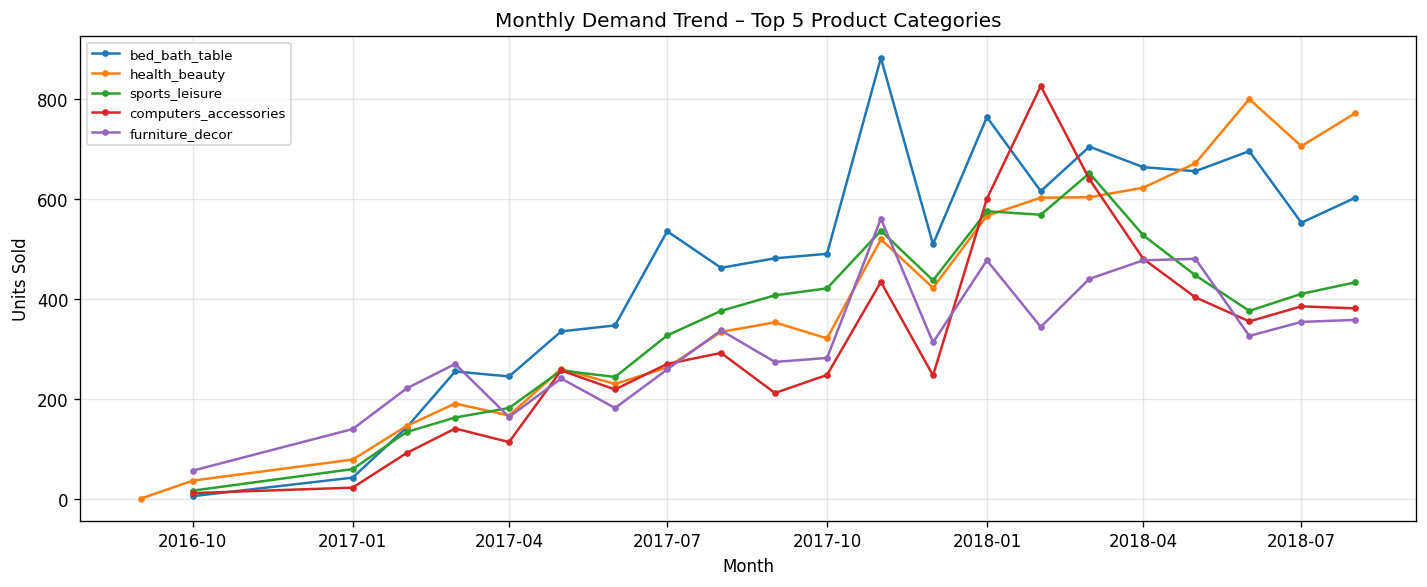

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
top5 = top_cats[:5]
for i, cat in enumerate(top5):
    sub = demand_top[demand_top["product_category_name"] == cat].sort_values("month")
    ax.plot(sub["month"], sub["total_quantity"], marker="o", markersize=3,
            label=cat, color=PALETTE[i])
ax.set_title("Monthly Demand Trend – Top 5 Product Categories")
ax.set_xlabel("Month")
ax.set_ylabel("Units Sold")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "fig1_demand_trend.png"))
plt.show()


### Figure 2 – Actual vs Predicted Demand

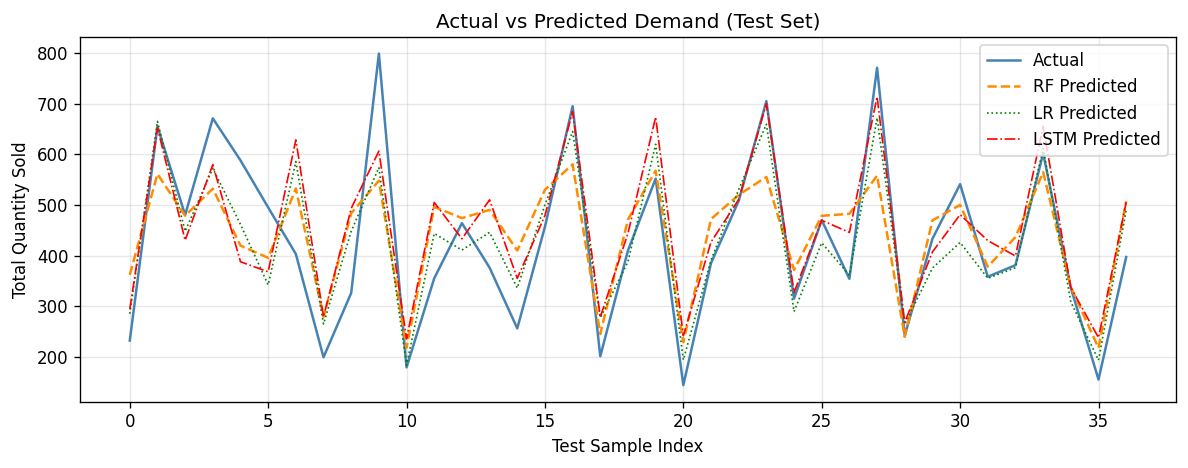

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
x_idx = range(len(y_test))
ax.plot(x_idx, y_test,      label="Actual",         color="steelblue",  linewidth=1.5)
ax.plot(x_idx, y_pred_rf,   label="RF Predicted",   color="darkorange", linewidth=1.5, linestyle="--")
ax.plot(x_idx, y_pred_lr,   label="LR Predicted",   color="green",      linewidth=1.0, linestyle=":")
ax.plot(x_idx, y_pred_lstm, label="LSTM Predicted", color="red",        linewidth=1.0, linestyle="-.")
ax.set_title("Actual vs Predicted Demand (Test Set)")
ax.set_xlabel("Test Sample Index")
ax.set_ylabel("Total Quantity Sold")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "fig2_actual_vs_predicted.png"))
plt.show()


### Figure 3 – Revenue Comparison by Pricing Method

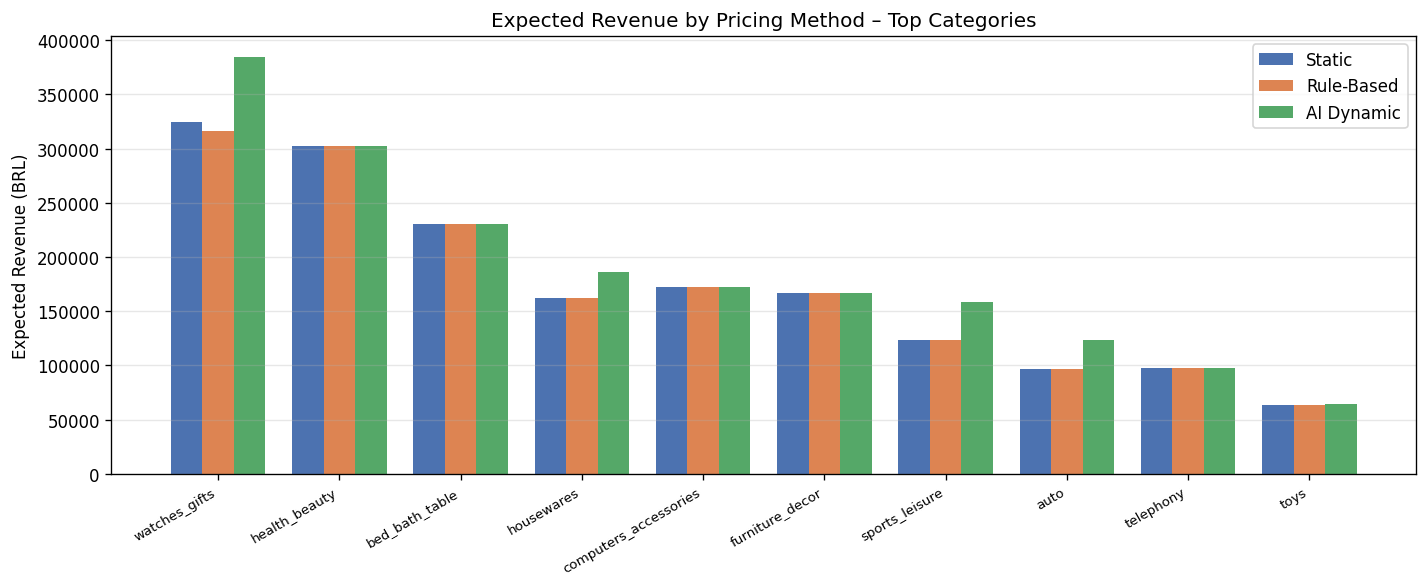

In [18]:
rev_by_cat = results_df.groupby("product_category_name")[
    ["exp_rev_static", "exp_rev_rule", "exp_rev_ai"]
].sum().reset_index()
rev_by_cat.columns = ["Category", "Static", "Rule-Based", "AI Dynamic"]

fig, ax = plt.subplots(figsize=(12, 5))
cats_sorted = rev_by_cat.sort_values("AI Dynamic", ascending=False)["Category"]
x = np.arange(len(cats_sorted))
width = 0.26
methods = ["Static", "Rule-Based", "AI Dynamic"]
colors  = ["#4C72B0", "#DD8452", "#55A868"]
for i, (method, color) in enumerate(zip(methods, colors)):
    vals = [rev_by_cat.set_index("Category").loc[c, method] for c in cats_sorted]
    ax.bar(x + i * width, vals, width, label=method, color=color)
ax.set_xticks(x + width)
ax.set_xticklabels(cats_sorted, rotation=30, ha="right", fontsize=8)
ax.set_title("Expected Revenue by Pricing Method – Top Categories")
ax.set_ylabel("Expected Revenue (BRL)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "fig3_revenue_comparison.png"))
plt.show()


### Figure 4 – AI-Recommended Price Change Distribution

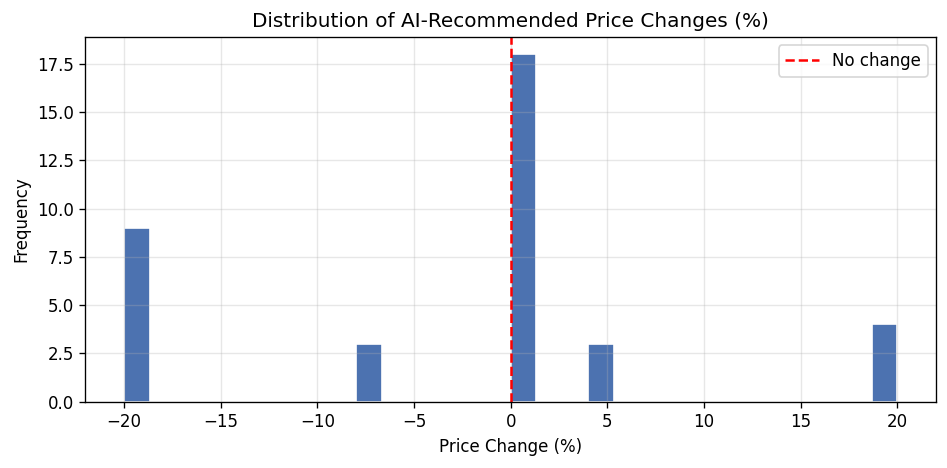

In [19]:
results_df["price_change_pct"] = (
    (results_df["ai_price"] - results_df["current_price"])
    / results_df["current_price"] * 100
)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(results_df["price_change_pct"], bins=30, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="red", linewidth=1.5, linestyle="--", label="No change")
ax.set_title("Distribution of AI-Recommended Price Changes (%)")
ax.set_xlabel("Price Change (%)")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "fig4_price_change_distribution.png"))
plt.show()


### Figure 5 – LSTM Training & Validation Loss

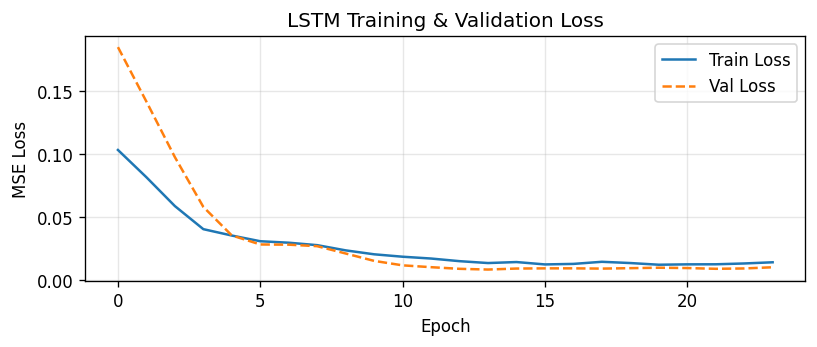

In [20]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history.history["loss"],     label="Train Loss")
ax.plot(history.history["val_loss"], label="Val Loss", linestyle="--")
ax.set_title("LSTM Training & Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "fig5_lstm_loss.png"))
plt.show()
